In [1]:
# %pip install scikit-learn
# %pip install category_encoders
# %pip install imbalanced-learn
# %pip install xgboost

In [2]:
import numpy as np
import pandas as pd
import random

### Encoding libaries
# import category_encoders as ce
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# from imblearn.over_sampling import SMOTE

### Machine Learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

### Model Search and Evaluation
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

### Plot library
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
### Ignore Warnings
import warnings 
warnings.filterwarnings("ignore")

In [4]:
### Set random number generator
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Bank Marketing: Encoding and Modelling

### 0. Data Loading and Feature Engineering

#### 0.1 Data Loading

In [8]:
bank_df = pd.read_csv(".//data//bank-full//bank-full.csv", sep=";")
# bank_df.head(5)

#### 0.2 Feature Engineering with pdays
- Following the exploratory data analysis, we separate feature 'pdays' into previous contact status 'pcont' and for previously contacted clients 'pcdays' for previous contacted days. For clients who 'pcont' status is negative, the 'pcdays' will be recored as 0 since the original 'pdays' starts with 1 for contacted clients.
- As for age, although categorized age into age range would provide comprehensible variable analysis during feature selection and evaluation. As our goal for this model is to predict, we will prioritize retaining information by using numerical variable instead of using a catagorized age variable.

In [10]:
### pdays
pdays_idx = bank_df.columns.get_loc("pdays")
bank_df.insert(
    pdays_idx + 1, # insert behind pdays
    "pcont", 
    np.where(bank_df["pdays"] == -1, "no", "yes") # new variable
)  

## Retain original pdays
pcont_idx = bank_df.columns.get_loc("pcont")
bank_df.insert(
    pcont_idx + 1,
    "pcdays",
    np.where(bank_df["pdays"] == -1, 0, bank_df["pdays"]) # if it is -1 change it to zero.
)

## remove the orignal pdays
pdays = bank_df.pop("pdays") # original pdays

In [11]:
bank_df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pcont,pcdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no,0,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no,0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no,0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no,0,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no,0,0,unknown,no


#### 0.3 Get Subset of Stratified Data
As we would like to explore multiple algorithms for this data, we will use a subset of data to train and test each models. This is to shortern the time to train each of the models.

In [13]:
def get_stratified_subset(df, target_col, pct, rnd_seed=42, insights=False):
    """
    Sample a subset of data specified in percentage from the original dataset. The algorithm functions by going through 
    each of the class in the 'target column' and sampled a proportion equal to the specified percentage.
    """
    ## Check user inputs
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"Error: Expected a pandas DataFrame, but received a {type(df)}.")
    
    subset_df = pd.DataFrame()
    
    ## Clone and shuffle
    clone_df = df.copy()
    clone_df = clone_df.sample(frac=1, random_state=rnd_seed).reset_index(drop=True) # random shuffling
    
    ## Group data
    tvars = clone_df[target_col].unique() # create target variables list
    for tvar in tvars:
        grouped_tvar = clone_df[clone_df[target_col]==tvar] # get subset data
        n_grouped_tvar = len(grouped_tvar) # get length
        sample_n = int(n_grouped_tvar * pct) # get the number that we need to sample
        sampled_tvar = grouped_tvar.sample(
            n=sample_n, # the number that we need to get to retain that sample pct
            random_state=rnd_seed # ensure reproducibility
        )
        subset_df=pd.concat(
            [subset_df, sampled_tvar],
            ignore_index=True
        )

    ## Reshuffle the grouped data
    subset_df = subset_df.sample(frac=1, random_state=rnd_seed).reset_index(drop=True)

    ## Get insights
    if insights == True:
        ## Get values
        og_counts = df[target_col].value_counts()
        og_pct = round(df[target_col].value_counts(normalize=True)*100, 2)
        sampled_counts = subset_df[target_col].value_counts()
        sampled_pct = round(subset_df[target_col].value_counts(normalize=True)*100, 2)
        ## Visualize
        compare_df = pd.DataFrame({
            "Class": og_counts.index,
            "Original_Count": og_counts.values,
            "Original_PCT": og_pct.values,
            "Sampled_Count": sampled_counts.values,
            "Sampled_PCT": sampled_pct.values
        })
        display(compare_df)
        
    ## Return the sampled data
    return subset_df

In [14]:
subset_bank = get_stratified_subset(
    df=bank_df, 
    target_col="y",
    pct=0.4,
    rnd_seed=SEED,
    insights=True
)

,Class,Original_Count,Original_PCT,Sampled_Count,Sampled_PCT
0,no,39922,88.3,15968,88.3
1,yes,5289,11.7,2115,11.7


### 1. Modelling Preprocessing 

#### 1.1 Categorical Variable Encoding
- Binary variables (Yes, No): default, housing, loan, pcont, y
- Nominal data (No order): job, marital, contact, poutcome
- Ordinal data (Categories with order): education
- Cyclical (Seasonal): day, month
- Discreate Numerical variables (no encoding required): age, balance, duration, campaign, pcdays, previous

In [17]:
## Columns
bi_cols = ["default", "housing", "loan", "pcont", "y"]
nom_cols = ["job", "contact", "poutcome"] # onehot encoder
ord_cols = ["education", "marital"]
cyc_cols = ["day", "month"]
dis_cols = ["age", "balance", "duration", "campaign", "pcdays", "previous"] ## We will scale it after all encoding

## Binary and Ordinal Encoding
ord_encoder = OrdinalEncoder(
    categories=[
        ["no", "yes"], ["no", "yes"], ["no", "yes"], ["no", "yes"], ["no", "yes"], # act as binary encoding
        ["unknown", "primary", "secondary", "tertiary"],
        ["single", "married", "divorced"]
    ]
)
## Nominal Encoding
nom_encoder = OneHotEncoder(sparse_output=False)

## Cyclical Encoding
def encode_months(df, month_col):
    months_map = {
        "jan": 1, "feb": 2, "mar": 3, "apr": 4,
        "may": 5, "jun": 6, "jul": 7, "aug": 8,
        "sep": 9, "oct": 10, "nov": 11, "dec": 12
    }
    clone_df = df.copy() # create a clone

    ## Create Sin and Cos for month
    clone_df[month_col] = clone_df[month_col].map(months_map)
    month_sin = np.sin(clone_df[month_col] * (2.*np.pi/12))
    month_cos = np.cos(clone_df[month_col] * (2.*np.pi/12))

    ## Insert new column after the original column
    month_idx = clone_df.columns.get_loc(month_col)
    clone_df.insert(month_idx+1, "month_sin", month_sin)
    clone_df.insert(month_idx+2, "month_cos", month_cos)
    clone_df.drop(columns=[month_col], inplace=True) # drop original column
    return clone_df

def encode_days(df, day_col):
    clone_df = df.copy()
    day_sin = np.sin(clone_df[day_col] * (2.*np.pi/31))
    day_cos = np.cos(clone_df[day_col] * (2.*np.pi/31))

    ## Insert new columns after the original column
    day_idx = clone_df.columns.get_loc(day_col)
    clone_df.insert(day_idx+1, "day_sin", day_sin)
    clone_df.insert(day_idx+2, "day_cos", day_cos)
    clone_df.drop(columns=[day_col], inplace=True) # drop original column
    return clone_df

In [18]:
## Encoding process
## Cyclincal Encoding
encoded_bank = encode_days(subset_bank, "day")
encoded_bank = encode_months(encoded_bank, "month")

## Binary and Ordinal Encoding
encoded_bank[bi_cols+ord_cols] = ord_encoder.fit_transform(encoded_bank[bi_cols+ord_cols])

## Nominal Encoding
encoded_nom = pd.DataFrame(
    nom_encoder.fit_transform(encoded_bank[nom_cols]),
    columns=nom_encoder.get_feature_names_out(nom_cols), # new column names
    index=encoded_bank.index  
)
encoded_bank = encoded_bank.drop(columns=nom_cols).join(encoded_nom)

## Check After encode
encoded_bank.head(5)

,age,marital,education,default,balance,housing,loan,day_sin,day_cos,month_sin,...,job_technician,job_unemployed,job_unknown,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,39,0.0,2.0,0.0,-114,1.0,0.0,0.571268,0.820763,8.660254e-01,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,30,0.0,3.0,0.0,596,0.0,0.0,0.724793,0.688967,1.224647e-16,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,34,2.0,2.0,0.0,-28,1.0,0.0,0.937752,0.347305,8.660254e-01,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,29,1.0,2.0,0.0,2121,0.0,0.0,-0.101168,-0.994869,8.660254e-01,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,48,1.0,2.0,0.0,3008,1.0,1.0,-0.485302,-0.874347,-5.000000e-01,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


#### 1.2 Data Split, Scaling, and Resampling

In [20]:
### Apply stratified sampling 70-30 ratio for train-test
X = encoded_bank.drop(columns = ["y"], axis = 1)
y = encoded_bank["y"]

## Train and Check (Test and Validate)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.3, # get 70% for training
    random_state = SEED, 
    stratify=y
) 

## Test and Validate - Validation occurs within the GridSearch
# X_val, X_test, y_val, y_test = train_test_split(
#     X_check, y_check, 
#     test_size=1/3, 
#     random_state=SEED, 
#     stratify=y_check # get 10% for val and 20% test
# ) 

#### 1.3 Data Scaling
Data Scaling is applied to provide a fair comparision between variables as numerical variable range in the data differs significatly from one another.

In [22]:
### Scaling - Only on discrete numerical columns
num_scaler = StandardScaler()
num_scaler.fit(X_train[dis_cols]) # using Standard Scaler fit to traning data to prevent leakage

## Transform only specific columns
X_train[dis_cols] = num_scaler.transform(X_train[dis_cols]) 
X_test[dis_cols] = num_scaler.transform(X_test[dis_cols]) 
# X_val[dis_cols] = num_scaler.transform(X_val[dis_cols])  

#### 1.4 Class Weighting
As our data is imbalanced with more non-subscribed compared to subscribed clients. We will be experimenting with [class weighting](https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html) in this study. Where machine learning model is penalized based on the proportion of classes.

In [24]:
## Compute class weight for imbalanced dataset
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(zip(np.unique(y_train), class_weights)) # transform into dict
sample_weights = np.array([class_weights[label] for label in y_train]) # assign weight to each y_training

### 2. Data Modelling with Hyperparameter Search
In this study we will be using Decision Tree, Random Forest, Adaboost, XGBoost, Logistic Regression, and Support Vector Machine models.

#### 2.1 Decision Tree

In [27]:
dt_model = DecisionTreeClassifier(
    random_state=SEED,
    class_weight="balanced" # combat with class imbalance
)

In [28]:
dt_params = {
    "max_depth": [5, 10, 20],
    "max_features": ["sqrt", "log2"]
}
scoring_params = {
    "auc": "roc_auc",
    "f1": "f1"
}

In [29]:
grid_search_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=dt_params,
    scoring=scoring_params,
    refit="auc",
    cv=5,
    return_train_score=True
)
grid_search_dt.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'max_depth': [5, 10, 20],
                         'max_features': ['sqrt', 'log2']},
             refit='auc', return_train_score=True,
             scoring={'auc': 'roc_auc', 'f1': 'f1'})

In [30]:
grid_search_dt.best_params_

{'max_depth': 10, 'max_features': 'sqrt'}

In [31]:
grid_search_dt.best_score_

np.float64(0.796476142650737)

In [32]:
dt_search_results = pd.DataFrame(grid_search_dt.cv_results_) # store train results

#### 2.2 Random Forest Model

In [34]:
rfc_model = RandomForestClassifier(
    bootstrap=True, 
    random_state=SEED,
    class_weight="balanced" # combat with class imbalance
)

In [35]:
rf_params = {
    "n_estimators": [50, 100, 150],
    "max_depth": [5, 10, 20],
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini", "entropy"]
}
scoring_params = {
    "auc": "roc_auc",
    "f1": "f1"
}

In [36]:
grid_search_rfc = GridSearchCV(
    estimator=rfc_model,
    param_grid=rf_params,
    scoring=scoring_params,
    refit="auc",
    cv=5,
    return_train_score=True
)
grid_search_rfc.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [50, 100, 150]},
             refit='auc', return_train_score=True,
             scoring={'auc': 'roc_auc', 'f1': 'f1'})

In [37]:
grid_search_rfc.best_params_

{'criterion': 'entropy',
 'max_depth': 20,
 'max_features': 'sqrt',
 'n_estimators': 150}

In [38]:
grid_search_rfc.best_score_

np.float64(0.9234004348533379)

In [39]:
rf_search_results = pd.DataFrame(grid_search_rfc.cv_results_) # store train results

#### 2.3 Adaboost Classifier

In [41]:
adb_model = AdaBoostClassifier(
    random_state=SEED
)

In [42]:
adb_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.1, 1],
}
scoring_params = {
    "auc": "roc_auc",
    "f1": "f1"
}

In [43]:
grid_search_adb = GridSearchCV(
    estimator=adb_model,
    param_grid=adb_params,
    scoring=scoring_params,
    refit="auc",
    cv=5,
    return_train_score=True
)
grid_search_adb.fit(X_train, y_train, sample_weight=sample_weights)

GridSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=42),
             param_grid={'learning_rate': [0.1, 1],
                         'n_estimators': [50, 100, 150]},
             refit='auc', return_train_score=True,
             scoring={'auc': 'roc_auc', 'f1': 'f1'})

In [44]:
grid_search_adb.best_params_

{'learning_rate': 1, 'n_estimators': 150}

In [45]:
grid_search_adb.best_score_

np.float64(0.9006114183032008)

In [46]:
adb_search_results = pd.DataFrame(grid_search_adb.cv_results_) # store train results

#### 2.4 XGBoost Classifier

In [48]:
xgb_model = XGBClassifier(
    random_state=SEED,
    device="cuda"
)

In [49]:
xgb_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.1, 1],
}
scoring_params = {
    "auc": "roc_auc",
    "f1": "f1"
}

In [50]:
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_params,
    scoring=scoring_params,
    refit="auc",
    cv=5,
    return_train_score=True
)
grid_search_xgb.fit(X_train, y_train, sample_weight=sample_weights)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device='cuda',
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             param_grid={'learning_rate': [0.1, 1],
                         'n_estimators': [50, 100, 150]},
             refit='auc', return_train_score=True,
             scoring={'auc': 'roc_auc', 'f1': 'f1'})

In [51]:
grid_search_xgb.best_params_

{'learning_rate': 0.1, 'n_estimators': 100}

In [52]:
grid_search_xgb.best_score_

np.float64(0.9240136781376831)

#### 2.5 Logistic Regression

In [54]:
lg_model = LogisticRegression(
    random_state=SEED,
    class_weight="balanced",
    solver="lbfgs"
)

In [55]:
lg_params = {
    "penalty": ["l1", "l2"],
    "C": [0.1, 1],
}
scoring_params = {
    "auc": "roc_auc",
    "f1": "f1"
}

In [56]:
grid_search_lg = GridSearchCV(
    estimator=lg_model,
    param_grid=lg_params,
    scoring=scoring_params,
    refit="auc",
    cv=5,
    return_train_score=True
)
grid_search_lg.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          random_state=42),
             param_grid={'C': [0.1, 1], 'penalty': ['l1', 'l2']}, refit='auc',
             return_train_score=True, scoring={'auc': 'roc_auc', 'f1': 'f1'})

In [57]:
grid_search_lg.best_params_

{'C': 0.1, 'penalty': 'l2'}

In [58]:
grid_search_lg.best_score_

np.float64(0.8881813985829126)

#### 2.6 Support Vector Classifier

In [60]:
svc_model = SVC(
    random_state=SEED,
    class_weight="balanced",
    gamma="scale"
)

In [61]:
svc_params = {
    "kernel": ["linear", "poly", "rbf"],
    "C": [1],
    "degree": [3],
}
scoring_params = {
    "auc": "roc_auc",
    "f1": "f1"
}

In [62]:
grid_search_svc = GridSearchCV(
    estimator=svc_model,
    param_grid=svc_params,
    scoring=scoring_params,
    refit="auc",
    cv=5,
    return_train_score=True
)
grid_search_svc.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(class_weight='balanced', random_state=42),
             param_grid={'C': [1], 'degree': [3],
                         'kernel': ['linear', 'poly', 'rbf']},
             refit='auc', return_train_score=True,
             scoring={'auc': 'roc_auc', 'f1': 'f1'})

In [63]:
grid_search_svc.best_params_

{'C': 1, 'degree': 3, 'kernel': 'rbf'}

In [64]:
grid_search_svc.best_score_

np.float64(0.9105239775319376)

### 3. Best Model Training and Comparision

In [66]:
## Define each model based on the best parameters
dtree = DecisionTreeClassifier(
    max_depth=10, max_features="sqrt", 
    random_state=SEED, class_weight="balanced"
)

rforest = RandomForestClassifier(
    criterion="entropy", max_depth= 20, max_features = "sqrt", 
    n_estimators = 150, bootstrap=True, 
    random_state=SEED, class_weight="balanced"
)

adaboost = AdaBoostClassifier(
    learning_rate=1, n_estimators=150,
    random_state=SEED
)

xgboost = XGBClassifier(
    learning_rate=0.1, n_estimators=100,
    random_state=SEED,
    device="cuda"
)

lreg = LogisticRegression(
    C=0.1, penalty="l2",
    random_state=SEED,
    class_weight="balanced",
    solver="lbfgs"
)

svc = SVC(
    C = 1, degree=3, 
    kernel="rbf",
    random_state=SEED,
    class_weight="balanced",
    probability=True,
    gamma="scale"
)

In [67]:
## Train each of the models - We avoid loop as some models require weight specifications
dtree.fit(X_train, y_train) # weight already specified
rforest.fit(X_train, y_train) # weight already specified
adaboost.fit(X_train, y_train, sample_weight=sample_weights)
xgboost.fit(X_train, y_train, sample_weight=sample_weights)
lreg.fit(X_train, y_train)
svc.fit(X_train, y_train)

SVC(C=1, class_weight='balanced', probability=True, random_state=42)

In [68]:
model_list = {
    "dtree": dtree,
    "rforest": rforest,
    "adaboost": adaboost,
    "xgboost": xgboost,
    "lreg": lreg,
    "svc": svc
}

In [69]:
model_metrics = []
roc_data = []

## Loop through models
for name, model in model_list.items():    
    ## Get prediction results
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    ## Compute Metrics
    auc_score = roc_auc_score(y_test, y_proba)
    acc_score = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    ## Store results
    model_metrics.append({
        "model": name,
        "auc": round(auc_score*100, 2),
        "f1-score": round(f1*100, 2),
        "precision": round(precision*100, 2),
        "recall": round(recall*100, 2),
        "accuracy": round(acc_score*100, 2)
    })

    ## Get ROC
    false_pos_rate, true_pos_rate, thresh = roc_curve(y_test, y_proba)
    roc_data.append({
        "model": name,
        "auc": auc_score, 
        "fpr": false_pos_rate,
        "tpr": true_pos_rate,
        "thresh": thresh
    })

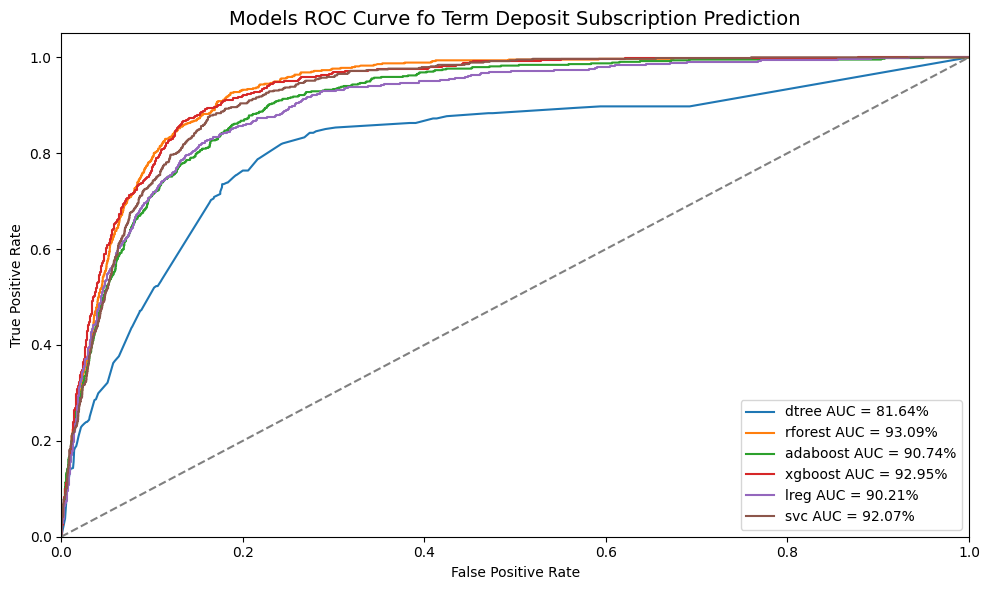

In [70]:
### Compare result for multiple models - ROC Curve
fig = plt.figure(figsize =(10, 6)) 
for entry in roc_data:
    plt.plot(
        entry["fpr"], entry["tpr"], 
        label=f'{entry["model"]} AUC = {round(entry["auc"] * 100, 2)}%'
    )
plt.plot([0, 1], [0, 1], linestyle="--", color="gray") 
plt.title("Models ROC Curve fo Term Deposit Subscription Prediction", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=10)
plt.ylabel("True Positive Rate", fontsize=10)
plt.margins(x=0, y=0) # set every margin to 0
plt.ylim(0, 1.05) # extend to get a gap on top
plt.tight_layout()
plt.legend()
plt.show();

In [71]:
### Compare result for multiple models - Tabular Data Comparision
model_metric_results = pd.DataFrame(model_metrics)
model_metric_results

,model,auc,f1-score,precision,recall,accuracy
0,dtree,81.64,46.68,33.61,76.38,79.58
1,rforest,93.09,44.79,64.97,34.17,90.14
2,adaboost,90.74,54.08,40.60,80.94,83.91
3,xgboost,92.95,60.46,46.80,85.35,86.93
4,lreg,90.21,54.21,40.32,82.68,83.65
5,svc,92.07,56.25,41.36,87.87,84.00


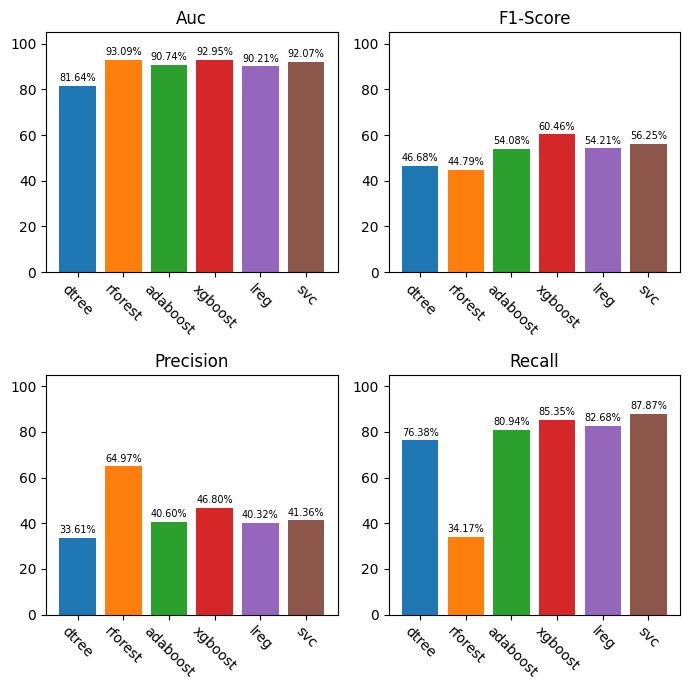

In [72]:
model_colors = {
    "dtree": "#1F77B4", # Blue
    "rforest": "#FF7F0E", # Orange
    "adaboost": "#2CA02C", # green
    "xgboost": "#D62728", # red
    "lreg": "#9467BD", # purple
    "svc": "#8C564B", # brown
} # Color ref: https://scottplot.net/cookbook/5.0/palettes/
plot_metrics = ["auc", "f1-score", "precision", "recall"]

## Loop and Plot
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(7,7))
axs_flat = axs.flatten()
for metric, axis in zip(plot_metrics, axs_flat):
    colors = [model_colors[model] for model in model_metric_results["model"]]
    axis.bar(
        model_metric_results["model"], 
        model_metric_results[metric],
        color=colors # accept only list
    )
    axis.set_title(metric.title())
    axis.set_ylim(0, 105)
    axis.set_xticklabels(model_metric_results["model"], rotation=-45)

    ## Plot Percentage
    for bar in axis.patches:
        axis.text(
            bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 2, 
            f"{bar.get_height():.2f}%", 
            ha="center", fontsize=7, color="black")
plt.tight_layout()
plt.show();

### 4. Modelling Summary

In [74]:
### XGBoost
y_predicted = xgboost.predict(X_test) # use xgboost algorithm

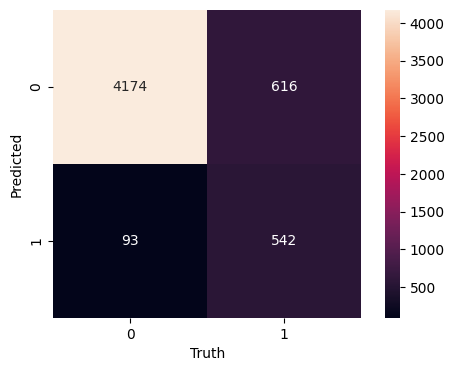

XGBoost Performance
Accuracy:	0.869309
F1-score:	0.763146
Precision:	0.723127
Recall:		0.862471
              precision    recall  f1-score   support

         0.0       0.98      0.87      0.92      4790
         1.0       0.47      0.85      0.60       635

    accuracy                           0.87      5425
   macro avg       0.72      0.86      0.76      5425
weighted avg       0.92      0.87      0.88      5425



In [75]:
### Classification Results
xgb_cm_results = confusion_matrix(y_test, y_predicted)
plt.figure(figsize=(6,4))
sns.heatmap(xgb_cm_results, 
            fmt = "d",
            square=True,
            annot=True
           )
plt.xlabel("Truth")
plt.ylabel("Predicted")
plt.show();

## Classification Performance
print("XGBoost Performance")
print("Accuracy:\t%f" % accuracy_score(y_test, y_predicted))
print("F1-score:\t%f" % f1_score(y_test, y_predicted, average="macro"))
print("Precision:\t%f" % precision_score(y_test, y_predicted, average="macro"))
print("Recall:\t\t%f" % recall_score(y_test, y_predicted, average="macro"))
print(classification_report(y_test, y_predicted))